In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist
from PIL import Image
import PIL
import pickle

#####################
#potting with plotly
import plotly.io as pio
import plotly.express as px
pio.renderers.default='browser'

from plotly.subplots import make_subplots
import plotly.graph_objects as go

print(f"Running on PyMC3 v{pm.__version__}")
print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.4
Running on PyMC3 v3.11.4


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

data=pd.read_csv('data_bt_dem.csv')
data=data.rename(columns={"participant": "participant_id"})
data=data.rename(columns={"acc": "response"})


data.head()


,Unnamed: 0,participant_id,index,session,draws,response,confidence_BT,gender,age,pdi,caps,pdi_group,caps_group
0,0,AD20,5,1.0,1.0,1.0,3.019048,0.0,18.0,71.0,154.0,high_pdi,high_caps
1,1,AD20,6,1.0,3.0,1.0,5.952381,0.0,18.0,71.0,154.0,high_pdi,high_caps
2,2,AD20,7,1.0,5.0,1.0,4.980952,0.0,18.0,71.0,154.0,high_pdi,high_caps
3,3,AD20,8,1.0,3.0,1.0,6.980952,0.0,18.0,71.0,154.0,high_pdi,high_caps
4,4,AD20,9,1.0,6.0,1.0,5.971429,0.0,18.0,71.0,154.0,high_pdi,high_caps


In [3]:
#data['response'].replace(0, -1, inplace=True)
from scipy import stats
data['z_draws']=stats.zscore(data['draws'])
data['z_pdi']=stats.zscore(data['pdi'])
data['z_caps']=stats.zscore(data['caps'])


In [4]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [5]:
participant_idx, participant = pd.factorize(data.participant_id)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(data)),
}

n=len(data)
hr_accuracy_bt_null= pm.Model(coords=coords) 
m_acc=data['response'].mean()


with hr_accuracy_bt_null as binomial_regression_model:
    
    mu_a = pm.Normal("mu_a", mu=0.5, sigma=0.5)
    sigma_a = pm.HalfNormal("sigma_a", 0.5)
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")

    # Model spec
    acc_like_reg = (a[participant_idx])
    
    p = pm.Deterministic("p", pm.math.invlogit(acc_like_reg))
    
    # Data likelihood
    accuracy_like = pm.Binomial(
        "accuracy_like", n=1, p=p, observed=data.response)
    
    

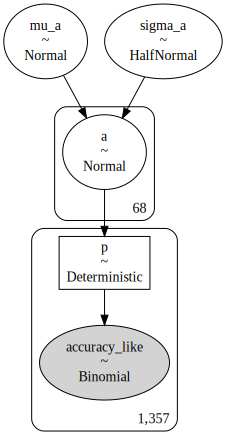

In [6]:
pm.model_to_graphviz(hr_accuracy_bt_null)

In [9]:
with hr_accuracy_bt_null:
     hr_accuracy_bt_null_trace = pm.sample(10000,tune=10000, target_accept=0.9, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, sigma_a, mu_a]


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 4 chains for 10_000 tune and 10_000 draw iterations (40_000 + 40_000 draws total) took 169 seconds.


In [7]:
# Save the model
with open('hr_accuracy_bt_null.pkl', 'wb') as file:
    pickle.dump(hr_accuracy_bt_null, file)
    
hr_accuracy_bt_null_trace.to_netcdf('hr_accuracy_bt_null_trace.nc', compress=False)    

'hr_accuracy_bt_null_trace.nc'

In [ ]:
# Load the model from the pickled file
with open('hr_accuracy_bt_null.pkl', 'rb') as file:
    hr_accuracy_bt_null = pickle.load(file)

hr_accuracy_bt_null_trace = az.from_netcdf('hr_accuracy_bt_null_trace.nc')


In [10]:
# Calculate the log likelihood using the log_likelihood method of the InferenceData object
log_likelihood = hr_accuracy_bt_null_trace.log_likelihood

# Compute the marginal likelihood (also known as the log pointwise predictive density)
marginal_likelihood = hr_accuracy_bt_null_trace.sum()

# Optionally, you can calculate the effective number of parameters (p_waic)
p_waic = az.waic(hr_accuracy_bt_null_trace).p_waic

# Optionally, you can calculate the Widely Applicable Information Criterion (WAIC)
waic = az.waic(hr_accuracy_bt_null_trace, scale='deviance')

print("Log likelihood:", log_likelihood.draw.mean())
print("Marginal likelihood (Log pointwise predictive density):", marginal_likelihood)
print("Effective number of parameters (p_waic):", p_waic)
print("WAIC:", waic)

/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details



Log likelihood: <xarray.DataArray 'draw' ()>
array(4999.5)
Marginal likelihood (Log pointwise predictive density): Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
Effective number of parameters (p_waic): 29.50338349283315
WAIC: Computed from 40000 by 1357 log-likelihood matrix

              Estimate       SE
deviance_waic   568.63    41.54
p_waic           29.50        -

There has been a warning during the calculation. Please check the results.


/Users/francescoscaramozzino/opt/anaconda3/envs/pymc3_env/lib/python3.9/site-packages/arviz/stats/stats.py:1405: UserWarning:

For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details

